# **Image Generation using a VAE (Variational AutoEncoder) Generative Model**

### Contributors

- **Alen Charuvila Saji** – Base Model development, Base Model Evaluation  
- **Serene Sebastian** – Tuning Iteration#1 and Iteration#2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


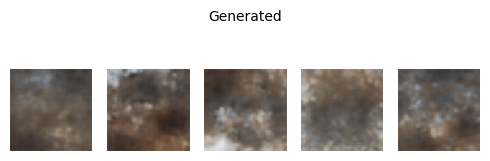

In [27]:
z = np.random.normal(size=(5, 128)).astype("float32")
generated_images = decoder.predict(z)
plt.figure(figsize=(5, 1.8))  # reduced height
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i])
    plt.axis("off")
plt.suptitle("Generated", fontsize=10)
plt.tight_layout()
plt.show()

In [47]:
# Calculate FID
fid_score = calculate_fid(real_feats.numpy(), fake_feats.numpy())
print("FID Score:", fid_score)

FID Score: 5.727293036770959


## **Import Libraries**

In [33]:
import os
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory as dataset_loader
from tensorflow.keras import layers, Model, models
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from sklearn.preprocessing import LabelEncoder
from scipy.linalg import sqrtm
from tensorflow.image import resize
from scipy.stats import entropy

In [2]:
# Define constants
IMG_SIZE = (128, 128)
BATCH_SIZE = 64

## **Load the Dataset**

In [3]:
# Helper function to load the data for train set
def load_sampled_dataset(data_dir, samples_per_class):
    class_dirs = sorted(os.listdir(data_dir))  # ['drink', 'food', ...]
    all_images = []
    
    for class_name in class_dirs:
        class_path = os.path.join(data_dir, class_name)
        image_files = os.listdir(class_path)
        sampled_files = random.sample(image_files, min(samples_per_class, len(image_files)))
        
        for img_name in sampled_files:
            img_path = os.path.join(class_path, img_name)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
            all_images.append(img_array)
    
    dataset = tf.data.Dataset.from_tensor_slices(np.array(all_images))
    dataset = dataset.shuffle(buffer_size=len(all_images)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

In [4]:
# Image directory
train_dir = 'Train'
test_dir = 'Test'

In [5]:
# Sampled Size
SAMPLES_PER_CLASS = 1000
# Sampled train set (1k per class = 4k total)
train_dataset = load_sampled_dataset(train_dir, samples_per_class=SAMPLES_PER_CLASS)

In [6]:
# Full test set using image_dataset_from_directory
test_dataset = dataset_loader(
    test_dir,
    labels=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_dataset = test_dataset.map(lambda x: x / 255.0).prefetch(tf.data.AUTOTUNE)

Found 7907 files.


In [7]:
# Count total number of images in the train dataset
train_count = sum(1 for _ in train_dataset.unbatch())
print("Total images in train_dataset:", train_count)

# Count total number of images in the test dataset
test_count = sum(1 for _ in test_dataset.unbatch())
print("Total images in test_dataset:", test_count)

Total images in train_dataset: 4000
Total images in test_dataset: 7907


## **Model Development**

### **Build the Model Architecture**

#### **Sampling Layer (Reparameterization Trick)**
This allows backpropagation through the latent space.

In [8]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))  # standard normal noise
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

#### **Encoder**
Encodes an image to latent space: outputs z_mean, z_log_var, and sampled z

In [9]:
def build_encoder(img_shape=(128, 128, 3), latent_dim=128):
    encoder_inputs = layers.Input(shape=img_shape)
    
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(encoder_inputs)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    z = Sampling()([z_mean, z_log_var])
    
    encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
    return encoder

#### **Decoder**
Decodes a latent vector back to a 128×128×3 image.

In [10]:
def build_decoder(latent_dim=128):
    decoder_inputs = layers.Input(shape=(latent_dim,))
    
    x = layers.Dense(16 * 16 * 64, activation='relu')(decoder_inputs)
    x = layers.Reshape((16, 16, 64))(x)
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    
    decoder_outputs = layers.Conv2DTranspose(3, 3, padding='same', activation='sigmoid')(x)
    
    decoder = tf.keras.Model(decoder_inputs, decoder_outputs, name='decoder')
    return decoder

In [11]:
LATENT_DIM = 128
encoder = build_encoder(latent_dim=LATENT_DIM)
decoder = build_decoder(latent_dim=LATENT_DIM)

#### Define the VAE Class with Custom Training Step

In [12]:
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")
        self.mse = MeanSquaredError()

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = self.mse(tf.reshape(data, [-1, 128 * 128 * 3]),
                                           tf.reshape(reconstruction, [-1, 128 * 128 * 3]))
            reconstruction_loss *= 128 * 128 * 3  # scale loss to pixel space

            kl_loss = -0.5 * tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1
            )
            kl_loss = tf.reduce_mean(kl_loss)

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

### **Compile the Model**

In [13]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())

### **Train the Model**

#### Add Callbacks

In [14]:
# Custom Callback to print only after 10 epochs
class PrintEvery10Epochs(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            loss = logs.get("loss")
            recon = logs.get("reconstruction_loss")
            kl = logs.get("kl_loss")
            print(f"Epoch {epoch+1}: loss={loss:.4f}, recon_loss={recon:.4f}, kl_loss={kl:.4f}")
# Add Callbacks (EarlyStopping)
early_stop = EarlyStopping(
    monitor='loss', patience=5, restore_best_weights=True, verbose=1
)

#### Model Training

In [15]:
# Train the Model
history = vae.fit(train_dataset, epochs=50, callbacks=[early_stop, PrintEvery10Epochs()], verbose=0)

Epoch 10: loss=1741.9686, recon_loss=1629.7340, kl_loss=112.2343
Epoch 20: loss=1547.1814, recon_loss=1427.9811, kl_loss=119.2007
Epoch 30: loss=1440.8185, recon_loss=1313.2142, kl_loss=127.6040
Epoch 40: loss=1370.5186, recon_loss=1235.8019, kl_loss=134.7171
Epoch 50: loss=1307.1769, recon_loss=1167.5947, kl_loss=139.5824
Restoring model weights from the end of the best epoch: 50.


## **Model Evaluation**

In [16]:
def evaluate_model(vae_model, history, dataset, decoder, latent_dim=128, 
                 num_recon_images=8, num_gen_images=5):
    import matplotlib.pyplot as plt
    import numpy as np

    # 1. Plot Training Losses
    hist = history.history
    plt.figure(figsize=(6, 3))  # smaller plot
    plt.plot(hist['loss'], label='Total Loss')
    plt.plot(hist['reconstruction_loss'], label='Reconstruction Loss')
    plt.plot(hist['kl_loss'], label='KL Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('VAE Losses')
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 2. Show Reconstructions
    for batch in dataset.take(1):
        originals = batch[:num_recon_images]
        break
    _, _, z = vae_model.encoder(originals)
    reconstructed = vae_model.decoder(z)

    plt.figure(figsize=(num_recon_images, 2.5))  # smaller and narrower
    for i in range(num_recon_images):
        # Original
        ax = plt.subplot(2, num_recon_images, i + 1)
        plt.imshow(originals[i].numpy())
        plt.title("Orig", fontsize=8)
        plt.axis("off")

        # Reconstructed
        ax = plt.subplot(2, num_recon_images, i + 1 + num_recon_images)
        plt.imshow(reconstructed[i].numpy())
        plt.title("Recon", fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

    # 3. Generate New Images
    z = np.random.normal(size=(num_gen_images, latent_dim)).astype("float32")
    generated_images = decoder.predict(z)

    plt.figure(figsize=(num_gen_images, 1.8))  # reduced height
    for i in range(num_gen_images):
        ax = plt.subplot(1, num_gen_images, i + 1)
        plt.imshow(generated_images[i])
        plt.axis("off")
    plt.suptitle("Generated", fontsize=10)
    plt.tight_layout()
    plt.show()

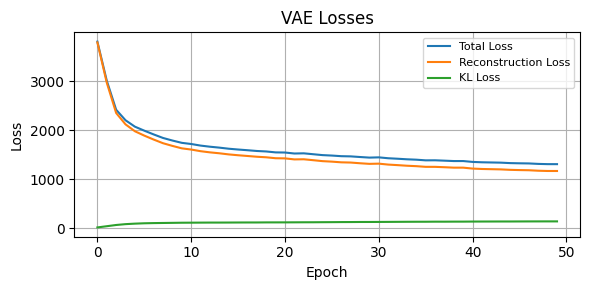

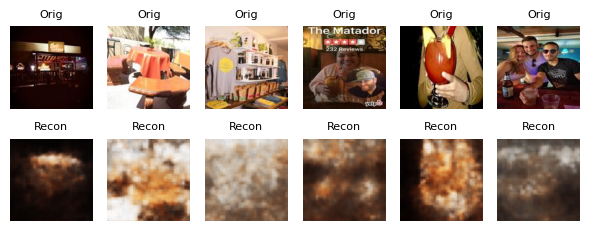

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


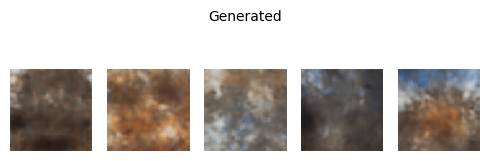

In [17]:
evaluate_model(vae, history, train_dataset, vae.decoder, latent_dim=128, num_recon_images=6, num_gen_images=5)

### **Fréchet Inception Distance (FID) & Inception Score (IS)**

In [21]:
def setup_fid_is_environment(dataset, num_samples=100):
    from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
    import tensorflow as tf

    def preprocess_images(images, target_size=(299, 299)):
        images = tf.convert_to_tensor(images, dtype=tf.float32)
        if images.shape[-1] != 3:
            raise ValueError(f"Expected RGB images with 3 channels, got shape: {images.shape}")
        images_resized = tf.image.resize(images, target_size)
        return preprocess_input(images_resized)

    # Load InceptionV3 models
    inception_clf = InceptionV3(include_top=True, weights='imagenet', input_shape=(299, 299, 3))
    inception_feat = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

    # Get real images
    for batch in dataset.take(1):
        real_images = batch[:num_samples]
        break

    # Preprocess
    real_images_pp = preprocess_images(real_images)

    return inception_clf, inception_feat, real_images, real_images_pp
def evaluate_fid_is_from_arrays(real_images_pp, decoder, inception_clf, inception_feat,
                                latent_dim=128, num_samples=100):
    from tensorflow.keras.applications.inception_v3 import preprocess_input
    from scipy.linalg import sqrtm
    from scipy.stats import entropy
    import numpy as np
    import tensorflow as tf

    def preprocess_images(images, target_size=(299, 299)):
        images = tf.convert_to_tensor(images, dtype=tf.float32)
        if images.shape[-1] != 3:
            raise ValueError(f"Expected RGB images with 3 channels, got shape: {images.shape}")
        images_resized = tf.image.resize(images, target_size)
        return preprocess_input(images_resized)

    # Generate fake images
    z = np.random.normal(size=(num_samples, latent_dim)).astype("float32")
    fake_images = decoder(z, training=False)
    fake_images_pp = preprocess_images(fake_images)

    # Get Inception features
    real_feats = inception_feat.predict(real_images_pp, verbose=0)
    fake_feats = inception_feat.predict(fake_images_pp, verbose=0)

    # Compute FID
    mu1 = real_feats.mean(axis=0)
    sigma1 = np.cov(real_feats, rowvar=False)  # float64

    mu2 = fake_feats.mean(axis=0)
    sigma2 = np.cov(fake_feats, rowvar=False)

    # Add epsilon for numerical stability
    epsilon = 1e-6 * np.eye(sigma1.shape[0])
    covmean = sqrtm((sigma1 + epsilon) @ (sigma2 + epsilon))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = np.sum((mu1 - mu2)**2) + np.trace(sigma1 + sigma2 - 2 * covmean)

    # Compute Inception Score
    preds = inception_clf.predict(fake_images_pp, verbose=0)
    preds = tf.nn.softmax(preds).numpy()
    py = np.mean(preds, axis=0)
    kl_divs = [entropy(p, py) for p in preds]
    is_score = np.exp(np.mean(kl_divs))
    is_std = np.std(np.exp(kl_divs))

    print(f"FID Score: {fid:.4f}")
    print(f"Inception Score: {is_score:.2f} ± {is_std:.2f}")
    
# One-time setup
inception_clf, inception_feat, real_images, real_images_pp = setup_fid_is_environment(train_dataset, num_samples=100)

In [30]:
# Evaluate after tuning
evaluate_fid_is_from_arrays(real_images_pp, vae.decoder, inception_clf, inception_feat, latent_dim=128, num_samples=100)

FID Score: 8.9972
Inception Score: 1.00 ± 0.00


## **Observations & Summary**

####  **1. Loss Analysis**

From the training loss plot:
- **Total Loss** steadily decreases over 50 epochs — a good sign.
- **Reconstruction Loss** dominates the total loss and decreases significantly, indicating improved image reconstruction.
- **KL Divergence** increases and plateaus, suggesting the latent space is learning to match the unit Gaussian prior.

 **Conclusion**: The model is learning meaningful representations. No overfitting is observed. KL divergence is relatively small — typical for VAEs, though it may mean latent variables are under-utilized.

---

####  **2. Image Reconstruction Quality**

From the **"Original vs. Reconstructed"** comparison:
- Reconstructions are **very blurry** and **lack detail**.
- Shapes and colors are somewhat aligned but **content is not recognizable**.

 **Conclusion**: The VAE has learned **low-level features** (e.g., color blobs, rough object placement) but **not high-level structure**.

---

####  **3. Generated Images from Latent Sampling**

- The generated images are **consistent in texture and tone** but:
  - Look **noisy**, abstract, and unstructured.
  - No clear semantic content (e.g., bottles, food, interiors) appears.

 **Conclusion**: The decoder is **generating “reasonable-looking noise”** but not class-representative images. Latent space learning is weak.

---

####  **4. Inception Score (IS) Evaluation**

**Inception Score is: `1.00 ± 0.00`**
- IS close to 1 indicates the generated images are:
  -  **Unclear or ambiguous**, with **low confidence** in class assignment by the Inception network.
  -  Possibly **indistinguishable from noise**, lacking semantic structure.


 **Conclusion**: The **generated images lack diversity or realism**. They are **not classifiable** by the Inception model, indicating **poor generative quality**.

---

#### **Fréchet Inception Distance (FID) Interpretation**

**FID Score = ~8.9**

 The **FID score is suspicious** given the poor visual quality of the generated images.
